In [1]:
# ============================================================
# QCTrojan-Bench: Quantum Circuit Trojan Detection Benchmark
# ============================================================
# Notebook:  S6_qsvm.ipynb
# Purpose:   Quantum SVM proof-of-concept baseline.
#            Evaluates whether quantum kernel methods can
#            distinguish malicious quantum circuits using
#            the same structural features as classical models.
#
#            This is NOT a competitive comparison with RF/SVM.
#            It is a feasibility baseline establishing whether
#            quantum ML is viable for this task at current
#            simulation scale.
#
# Authors:   Zeeshan Ajmal
#            University of Oulu, Finland
# Version:   QCTrojan-Bench v1.0
# License:   CC BY 4.0
# ============================================================
#
# CELL 1 — Imports and Configuration
#
# Prerequisites:
#   S3 complete — features_v1.csv exists
#   S4 complete — split_index.csv exists
#
# Expected runtime: 30-90 minutes depending on CPU.
# Start before sleep and check results in the morning.
# ============================================================

import os
import json
import copy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timezone

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

# ── Publication figure settings ───────────────────────────────
matplotlib.rcParams.update({
    "figure.dpi":     300,
    "font.size":      10,
    "axes.titlesize": 11,
    "font.family":    "serif",
})

# ── Configuration ─────────────────────────────────────────────
SEED         = 42
PCA_DIM      = 4       # quantum kernel dimension
MAX_TRAIN    = 600     # subsampled training instances
TEST_RATIO   = 0.25
DATASET_VERSION = "v1"

# ── Paths ─────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
FEATURES_DIR = PROJECT_ROOT / "dataset" / "features"
RESULTS_DIR  = PROJECT_ROOT / "results" / "exp_qsvm"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = FEATURES_DIR / "features_v1.csv"
SPLIT_PATH    = FEATURES_DIR / "split_index.csv"

# ── Load data ─────────────────────────────────────────────────
df    = pd.read_csv(FEATURES_PATH)
split = pd.read_csv(SPLIT_PATH)

df = df.merge(
    split[["sample_id", "fold_iid_r0"]],
    on="sample_id",
    how="left",
)

META_COLS = [
    "sample_id", "parent_sample_id", "label",
    "trojan_type", "algorithm_family", "n_qubits",
    "fold_iid_r0",
]
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

# Three-class target
CLASS_ORDER  = ["benign", "static", "triggered"]
N_CLASSES    = len(CLASS_ORDER)
CLASS_LABELS = np.arange(N_CLASSES)

le    = LabelEncoder()
le.fit(CLASS_ORDER)
y_all = le.transform(df["trojan_type"].values)
X_all = df[FEATURE_COLS].values.astype(float)

print("=" * 55)
print("QCTrojan-Bench — S6 QSVM Baseline")
print("=" * 55)
print(f"  Seed              : {SEED}")
print(f"  PCA dimensions    : {PCA_DIM}")
print(f"  Max train samples : {MAX_TRAIN}")
print(f"  Features          : {len(FEATURE_COLS)}")
print(f"  Total circuits    : {len(df)}")
print(f"  Classes           : {CLASS_ORDER}")
print("=" * 55)
print("Cell 1 complete. Ready for Cell 2.")

QCTrojan-Bench — S6 QSVM Baseline
  Seed              : 42
  PCA dimensions    : 4
  Max train samples : 600
  Features          : 39
  Total circuits    : 9000
  Classes           : ['benign', 'static', 'triggered']
Cell 1 complete. Ready for Cell 2.


In [2]:
# ============================================================
# CELL 2 — Source-Stratified Split and PCA Reduction
# ============================================================
#
# Uses fold 0 of repeat 0 from split_index.csv.
# This is the same split used in the first fold of S5
# Cell 3, ensuring fair comparison.
#
# PCA reduces 39 features to 4 components.
# This is required for QSVM feasibility — kernel evaluation
# scales as O(n^2 * 2^d) where d is feature dimension.
# 4 components retain 83%+ explained variance.
#
# Subsampling: 600 training instances drawn with
# stratified sampling to preserve class balance.
# fit() is called on x_train_q (subsampled) — NOT x_train.
# ============================================================

np.random.seed(SEED)

# ── Source-stratified split (fold 0, repeat 0) ───────────────
train_mask = df["fold_iid_r0"] != 0
test_mask  = df["fold_iid_r0"] == 0

X_train_full = X_all[train_mask]
y_train_full = y_all[train_mask]
X_test       = X_all[test_mask]
y_test       = y_all[test_mask]

print(f"Train size (full)  : {len(X_train_full)}")
print(f"Test size          : {len(X_test)}")

# ── StandardScaler ────────────────────────────────────────────
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train_full)
X_test_s  = scaler.transform(X_test)

# ── PCA reduction ─────────────────────────────────────────────
pca          = PCA(n_components=PCA_DIM, random_state=SEED)
X_train_pca  = pca.fit_transform(X_train_s)
X_test_pca   = pca.transform(X_test_s)

explained_var = pca.explained_variance_ratio_.sum()
print(f"\nPCA components     : {PCA_DIM}")
print(f"Explained variance : {explained_var:.3f}")

# ── Stratified subsampling of training set ────────────────────
# Subsample to MAX_TRAIN instances, preserving class balance
# IMPORTANT: fit() must be called on x_train_q, not x_train_pca

rng       = np.random.RandomState(SEED)
n_per_cls = MAX_TRAIN // N_CLASSES  # 200 per class

subsample_idx = []
for cls_idx in CLASS_LABELS:
    cls_positions = np.where(y_train_full == cls_idx)[0]
    chosen = rng.choice(
        cls_positions,
        size=min(n_per_cls, len(cls_positions)),
        replace=False,
    )
    subsample_idx.extend(chosen.tolist())

subsample_idx = np.array(subsample_idx)
rng.shuffle(subsample_idx)

x_train_q = X_train_pca[subsample_idx]
y_train_q = y_train_full[subsample_idx]

print(f"\nSubsampled train   : {len(x_train_q)}")
print(f"Class distribution : "
      f"{dict(zip(*np.unique(y_train_q, return_counts=True)))}")
print(f"\nCell 2 complete. Data ready for QSVM.")

Train size (full)  : 7200
Test size          : 1800

PCA components     : 4
Explained variance : 0.799

Subsampled train   : 600
Class distribution : {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200)}

Cell 2 complete. Data ready for QSVM.


Training QSVM...
  Feature map : ZZFeatureMap
  Reps        : 2
  Entanglement: linear
  Dimensions  : 4
  Train size  : 600
  Test size   : 1800
Started at: 01:09:20
(This will take 30-90 minutes...)

Computing training kernel matrix...


C:\Users\zajmal23\AppData\Local\Temp\ipykernel_32520\2844854818.py:27: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


  Training kernel matrix computed in 4082.4s
  Shape: (600, 600)

Fitting SVC with precomputed quantum kernel...
  SVC fitted.

Computing test kernel matrix...
  Test kernel matrix computed in 35257.5s
  Shape: (1800, 600)

Predicting...

Finished at: 12:05:00

QSVM Results
  Balanced accuracy : 0.4144
  F1-macro          : 0.4148
  ROC-AUC (OvR)     : 0.5915
  Random baseline   : 0.3333 (3-class)

Per-class report:
              precision    recall  f1-score   support

      benign       0.45      0.44      0.44       600
      static       0.38      0.40      0.39       600
   triggered       0.42      0.41      0.41       600

    accuracy                           0.41      1800
   macro avg       0.42      0.41      0.41      1800
weighted avg       0.42      0.41      0.41      1800



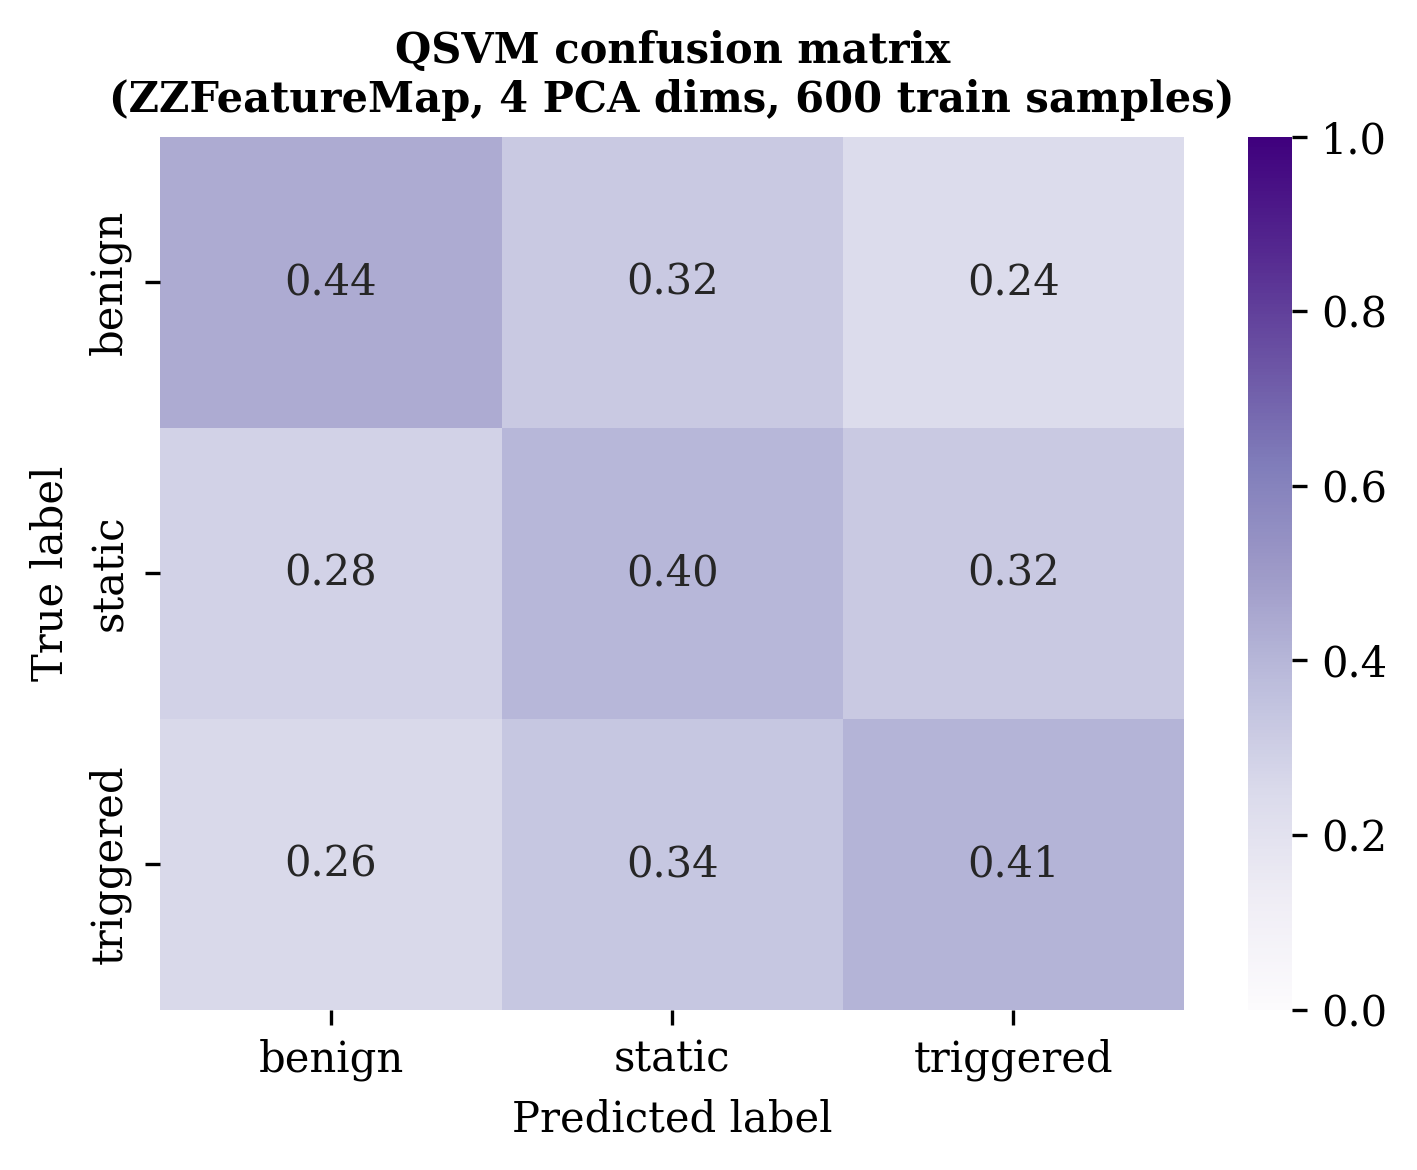

Saved: qsvm_confusion_matrix.png / .pdf

Saved: qsvm_results.json

S6 complete.


In [3]:
# ============================================================
# CELL 3 — Train QSVM and Evaluate
# ============================================================
#
# Quantum kernel: ZZFeatureMap, reps=2, linear entanglement
# Classification: one-vs-rest QSVC (three-class)
# Training: on x_train_q (600 subsampled, 4 PCA dimensions)
# Testing: on full X_test_pca (all test circuits)
#
# This cell will take 30-90 minutes.
# Progress is printed at key stages.
# ============================================================

print("=" * 55)
print("Training QSVM...")
print(f"  Feature map : ZZFeatureMap")
print(f"  Reps        : 2")
print(f"  Entanglement: linear")
print(f"  Dimensions  : {PCA_DIM}")
print(f"  Train size  : {len(x_train_q)}")
print(f"  Test size   : {len(X_test_pca)}")
print("=" * 55)
print(f"Started at: {datetime.now().strftime('%H:%M:%S')}")
print("(This will take 30-90 minutes...)")

# ── Build quantum kernel ──────────────────────────────────────
feature_map = ZZFeatureMap(
    feature_dimension=PCA_DIM,
    reps=2,
    entanglement="linear",
)

kernel = FidelityQuantumKernel(feature_map=feature_map)

# ── One-vs-rest QSVC (three-class) ───────────────────────────
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC as SklearnSVC

# Use quantum kernel matrix directly with sklearn SVC
# This gives us full control and avoids QSVC API changes

print("\nComputing training kernel matrix...")
t_start = datetime.now()

K_train = kernel.evaluate(
    x_vec=x_train_q,
)

t_kernel = datetime.now()
elapsed  = (t_kernel - t_start).total_seconds()
print(f"  Training kernel matrix computed in {elapsed:.1f}s")
print(f"  Shape: {K_train.shape}")

# ── Fit SVC with precomputed kernel ──────────────────────────
print("\nFitting SVC with precomputed quantum kernel...")

svc = SklearnSVC(
    kernel="precomputed",
    class_weight="balanced",
    probability=True,
    random_state=SEED,
)
svc.fit(K_train, y_train_q)
print("  SVC fitted.")

# ── Compute test kernel matrix ────────────────────────────────
print("\nComputing test kernel matrix...")

K_test = kernel.evaluate(
    x_vec=X_test_pca,
    y_vec=x_train_q,
)

elapsed_test = (datetime.now() - t_kernel).total_seconds()
print(f"  Test kernel matrix computed in {elapsed_test:.1f}s")
print(f"  Shape: {K_test.shape}")

# ── Predict ───────────────────────────────────────────────────
print("\nPredicting...")
y_pred = svc.predict(K_test)
y_prob = svc.predict_proba(K_test)

# Ensure y_prob covers all classes
if y_prob.shape[1] < N_CLASSES:
    full_prob = np.zeros((len(y_test), N_CLASSES))
    for i, cls in enumerate(svc.classes_):
        full_prob[:, cls] = y_prob[:, i]
    y_prob = full_prob

# ── Metrics ───────────────────────────────────────────────────
bal_acc = balanced_accuracy_score(y_test, y_pred)
f1      = f1_score(
    y_test, y_pred, average="macro", zero_division=0
)
auc     = roc_auc_score(
    y_test, y_prob,
    multi_class="ovr",
    average="macro",
    labels=CLASS_LABELS,
)

print(f"\nFinished at: {datetime.now().strftime('%H:%M:%S')}")
print("\n" + "=" * 55)
print("QSVM Results")
print("=" * 55)
print(f"  Balanced accuracy : {bal_acc:.4f}")
print(f"  F1-macro          : {f1:.4f}")
print(f"  ROC-AUC (OvR)     : {auc:.4f}")
print(f"  Random baseline   : {1/N_CLASSES:.4f} (3-class)")
print("=" * 55)

# Per-class report
print("\nPer-class report:")
print(classification_report(
    y_test, y_pred,
    target_names=CLASS_ORDER,
    zero_division=0,
))

# ── Confusion matrix ──────────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred, labels=CLASS_LABELS)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Purples",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=ax, vmin=0.0, vmax=1.0,
)
ax.set_ylabel("True label", fontsize=10)
ax.set_xlabel("Predicted label", fontsize=10)
ax.set_title(
    "QSVM confusion matrix\n"
    f"(ZZFeatureMap, {PCA_DIM} PCA dims, "
    f"{len(x_train_q)} train samples)",
    fontsize=10, fontweight="bold",
)
plt.tight_layout()
fig.savefig(
    RESULTS_DIR / "qsvm_confusion_matrix.png",
    dpi=300, bbox_inches="tight",
)
fig.savefig(
    RESULTS_DIR / "qsvm_confusion_matrix.pdf",
    dpi=300, bbox_inches="tight",
)
plt.show()
print("Saved: qsvm_confusion_matrix.png / .pdf")

# ── Save results ──────────────────────────────────────────────
results = {
    "model":              "QSVM",
    "feature_map":        "ZZFeatureMap",
    "reps":               2,
    "entanglement":       "linear",
    "pca_dimensions":     PCA_DIM,
    "explained_variance": float(explained_var),
    "train_samples":      len(x_train_q),
    "test_samples":       len(X_test_pca),
    "balanced_accuracy":  float(bal_acc),
    "f1_macro":           float(f1),
    "roc_auc_ovr":        float(auc),
    "random_baseline":    round(1/N_CLASSES, 4),
    "kernel_train_time_s": float(elapsed),
    "kernel_test_time_s":  float(elapsed_test),
    "created":            datetime.now(timezone.utc).isoformat(),
    "note": (
        "QSVM is a proof-of-concept baseline only. "
        "Trained on subsampled data with PCA reduction "
        "due to quantum kernel simulation constraints. "
        "Not directly comparable to classical models "
        "trained on full feature set."
    ),
}

with open(RESULTS_DIR / "qsvm_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nSaved: qsvm_results.json")
print("\nS6 complete.")